In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sequence_jacobian import simple, combine, create_model

In [2]:
@simple
def interest(K, L, Z, alpha, delta):
    r = alpha * Z * (K / L) ** (alpha-1) - delta
    return r
@simple
def wage(K, L, Z, alpha):
    w = (1 - alpha) * Z * (K / L) ** alpha
    return w

@simple
def firm(K, L, Z, alpha):
    Y = Z * K ** alpha * L ** (1 - alpha)
    return Y
    
@simple
def euler_equation(L, w, eis, frisch, vphi):
    C = (w / vphi / L ** (1 / frisch)) ** eis
    return C

@simple
def investment(K, delta):
    I = K - (1 - delta) * K(-1)
    return I

@simple
def mkt_clearing(r, C, Y, I, eis, beta):
    goods_mkt = Y - C - I
    euler = C ** (-1 / eis) - beta * (1 + r(+1)) * C(+1) ** (-1 / eis)
    return goods_mkt, euler

In [3]:
rbc = create_model([interest, wage, firm, euler_equation, investment, mkt_clearing], name="RBC")

print(rbc)
print(f"Blocks: {rbc.blocks}")

<Model 'RBC'>
Blocks: [<SimpleBlock 'investment'>, <SimpleBlock 'firm'>, <SimpleBlock 'wage'>, <SimpleBlock 'euler_equation'>, <SimpleBlock 'interest'>, <SimpleBlock 'mkt_clearing'>]


In [4]:
unknowns = ['K', 'L']
targets = ['euler', 'goods_mkt']
inputs = ['Z']

In [5]:
calibration = {"L": 1., "Z": 1., "r": 0.01, "eis": 1., "frisch": 1., "delta": 0.025, "alpha": 0.33}
unknowns_ss = {"vphi": 0.9, "beta": 0.99, "K": 2., "Z": 1.}
targets_ss = {"goods_mkt": 0., "r": 0.01, "euler": 0., "Y": 1.}

In [6]:
ss = rbc.solve_steady_state(calibration, unknowns_ss, targets_ss, solver="hybr")

print(ss)

<SteadyStateDict: ['L', 'Z', 'r', 'eis', 'frisch', 'delta', 'alpha', 'vphi', 'beta', 'K', 'I', 'Y', 'w', 'C', 'goods_mkt', 'euler']>


In [7]:
print(f"Euler equation: {ss['euler']}")
print(f"Goods market clearing: {ss['goods_mkt']}")

Euler equation: 2.220446049250313e-16
Goods market clearing: 2.220446049250313e-16


In [8]:
G = rbc.solve_jacobian(ss, unknowns, targets, inputs, T=300)

print(G)

<JacobianDict outputs=['K', 'L', 'r', 'w', 'Y', 'C', 'I', 'goods_mkt', 'euler'], inputs=['Z']>


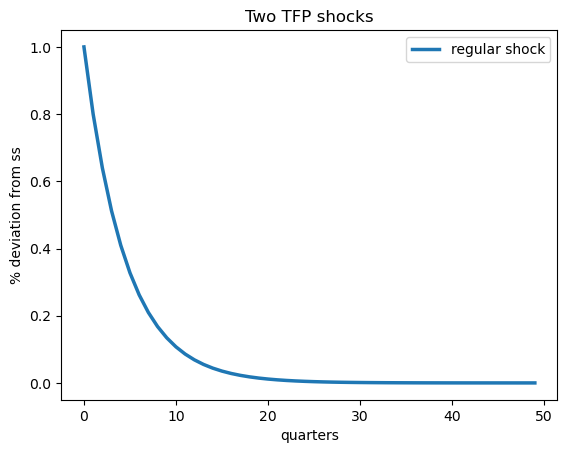

In [9]:
T, impact, rho = 300, 0.01, 0.8
dZ = np.empty((T, 2))
dZ[:, 0] = impact * ss['Z'] * rho**np.arange(T)

plt.plot(100*dZ[:50, 0]/ss['Z'], label='regular shock', linewidth=2.5)
plt.title(r'Two TFP shocks')
plt.ylabel(r'% deviation from ss')
plt.xlabel(r'quarters')
plt.legend()
plt.show()

In [10]:
z_shock = 100 * dZ / ss['Z']
dC = 100 * G['C']['Z'] @ dZ / ss['C']
dY = 100 * G['Y']['Z'] @ dZ / ss['Y']
dL = 100 * G['L']['Z'] @ dZ / ss['L']
dK = 100 * G['K']['Z'] @ dZ / ss['K']
dr = 100 * G['r']['Z'] @ dZ / ss['r']
dw = 100 * G['w']['Z'] @ dZ / ss['w']
dI = 100 * G['I']['Z'] @ dZ / ss['I']

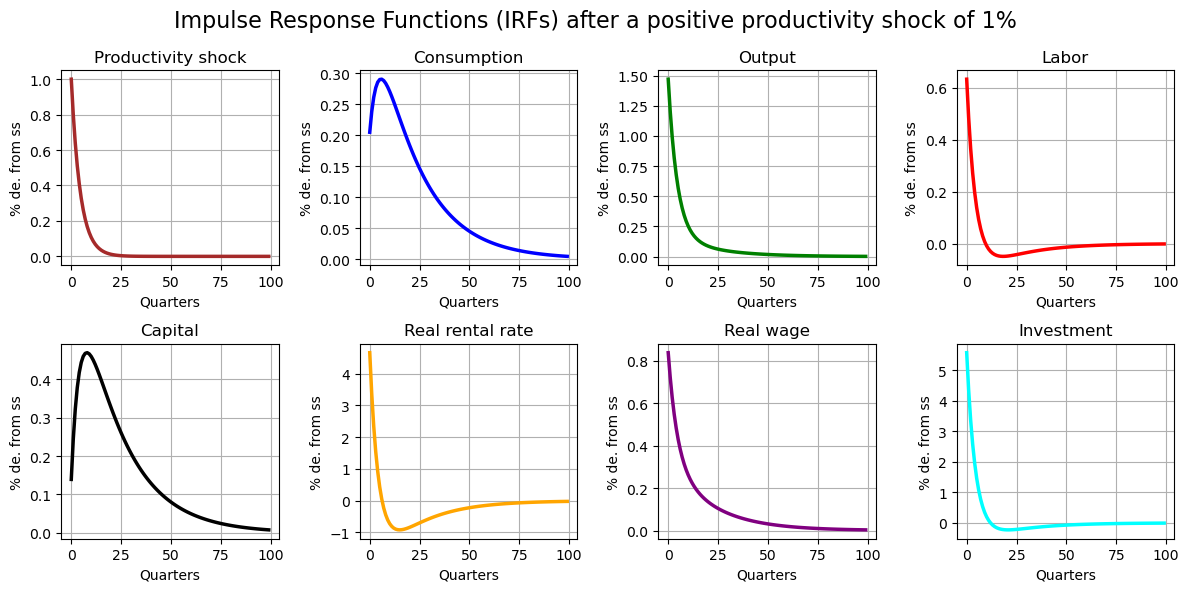

In [11]:
fig, axs = plt.subplots(2, 4, figsize=(12,6))
series = [(z_shock, 'Productivity shock', 'brown'), (dC, 'Consumption', 'blue'), (dY, 'Output', 'green'), (dL, 'Labor', 'red'), 
          (dK, 'Capital', 'black'), (dr, 'Real rental rate', 'orange'), (dw, 'Real wage', 'purple'), (dI, 'Investment', 'cyan')]

for ax, (data, title, color) in zip(axs.flatten(), series):
    ax.plot(data[:100,0], linewidth=2.5, color=color)
    ax.set_title(title)
    ax.set_xlabel('Quarters')
    ax.set_ylabel('% de. from ss')
    #ax.set_ylim(-1,6)
    ax.grid(True)

fig.suptitle('Impulse Response Functions (IRFs) after a positive productivity shock of 1%', fontsize=16)
plt.tight_layout()
plt.show()